In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import networkx as nx
import numpy as np

#指定中文字体
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 提取数据集
bike_sharing = fetch_ucirepo(id=275)

# 数据（转换为 pandas 的 DataFrame）
data = bike_sharing.data.features
targets = bike_sharing.data.targets


In [2]:
# 统计基本信息
df = pd.DataFrame(data)
print('统计基本信息')
#  查看数据的形状
print(f"数据的形状：{df.shape}")

#  查看数据的列信息
print(f"数据的列名：{df.columns}")

#  查看数据的类型
print(f"数据的类型：{df.dtypes}")

# 查看数据的描述性统计信息
print(f"数据的描述性统计：\n{df.describe()}")

# 查看是否有缺失值
print(f"数据是否有缺失值：\n{df.isnull().any()}")

统计基本信息
数据的形状：(17379, 13)
数据的列名：Index(['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')
数据的类型：dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
dtype: object
数据的描述性统计：
             season            yr          mnth            hr       holiday  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       2.501640      0.502561      6.537775     11.546752      0.028770   
std        1.106918      0.500008      3.438776      6.914405      0.167165   
min        1.000000      0.000000      1.000000      0.000000      0.000000   
25%        2.000000      0.000000      4.000000      6.000000      0.000000   
50%        3.00

散点图


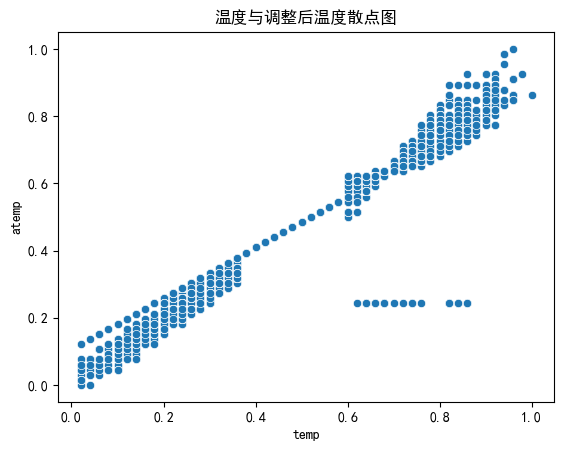

In [3]:
# 排除日期列 减少计算难度
data_no_date = data.drop(columns=['dteday'])

# 散点图
print('散点图')
sns.scatterplot(data=data_no_date, x='temp', y='atemp')
plt.title('温度与调整后温度散点图')
plt.show()

气泡图


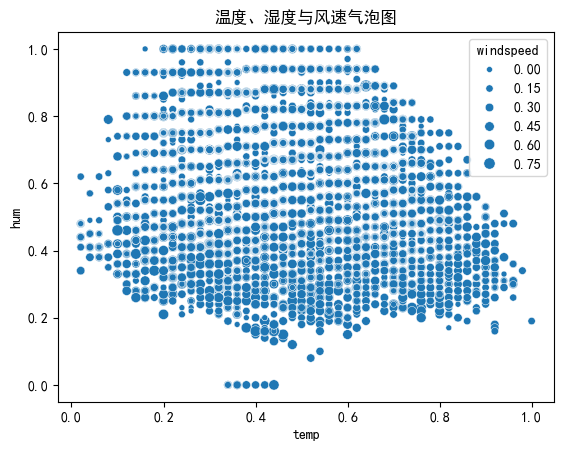

In [4]:
# 气泡图
print('气泡图')
sns.scatterplot(data=data_no_date, x='temp', y='hum', size='windspeed')
plt.title('温度、湿度与风速气泡图')
plt.show()

竖向柱形图


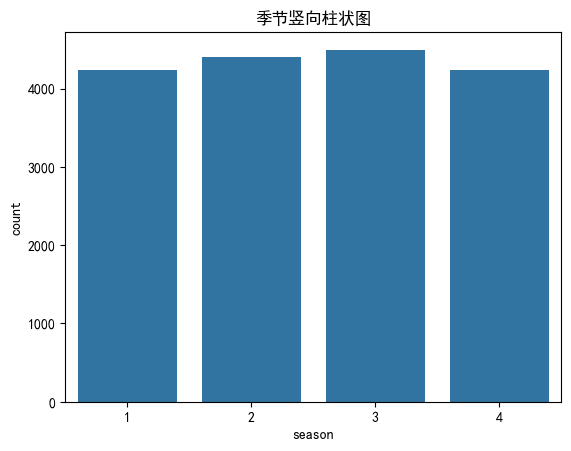

In [5]:
# 竖向柱状图（以季节为例）
print('竖向柱形图')
sns.countplot(data=data_no_date, x='season')
plt.title('季节竖向柱状图')
plt.show()


横向柱形图


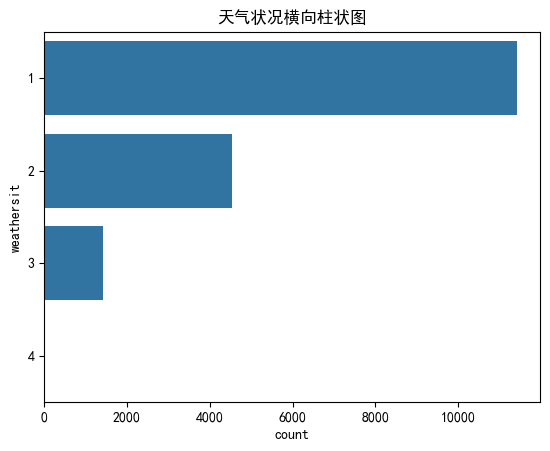

In [6]:
# 横向柱状图（以天气状况为例）
print('横向柱形图')
sns.countplot(data=data_no_date, y='weathersit')
plt.title('天气状况横向柱状图')
plt.show()


极坐标柱形图


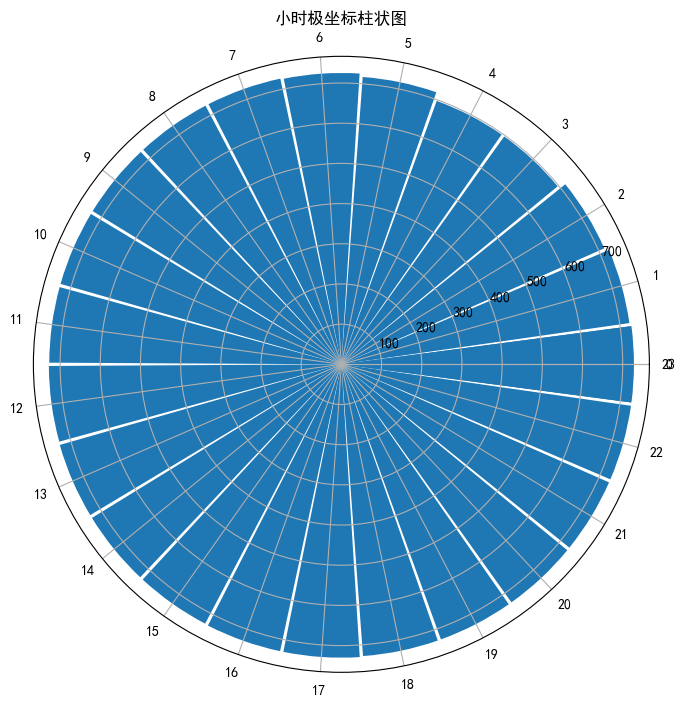

In [7]:
# 极坐标柱状图（以小时为例）
print('极坐标柱形图')
hours = data_no_date['hr'].value_counts().sort_index()
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
theta = np.linspace(0, 2 * np.pi, len(hours))
width = (2 * np.pi) / len(hours)
bars = ax.bar(theta, hours, width=width, bottom=0)
ax.set_xticks(theta)
ax.set_xticklabels(range(0, 24))
plt.title('小时极坐标柱状图')
plt.show()

有数据信息的饼状图


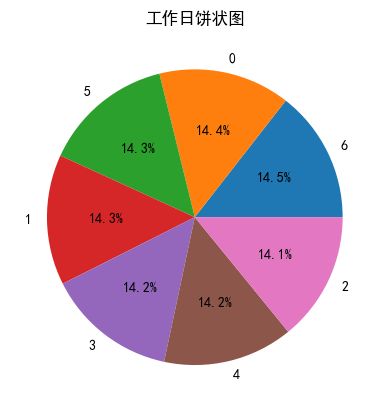

In [8]:
# 有数据信息的饼状图（以工作日为例）
print('有数据信息的饼状图')
weekday_counts = data_no_date['weekday'].value_counts()
plt.pie(weekday_counts, labels=weekday_counts.index, autopct='%1.1f%%')
plt.title('工作日饼状图')
plt.show()

 收缩显示的饼状图


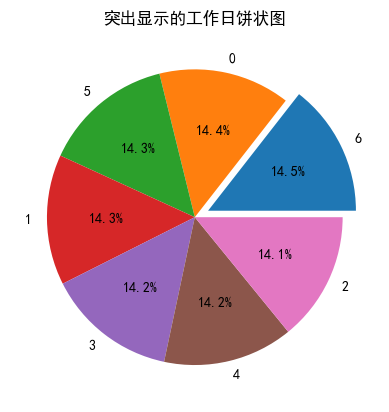

In [9]:
# 收缩显示的饼状图（突出显示某一个工作日，比如 0）
print(' 收缩显示的饼状图')
explode = [0.1 if i == 0 else 0 for i in range(len(weekday_counts))]
plt.pie(weekday_counts, labels=weekday_counts.index, autopct='%1.1f%%', explode=explode)
plt.title('突出显示的工作日饼状图')
plt.show()


立体线形图


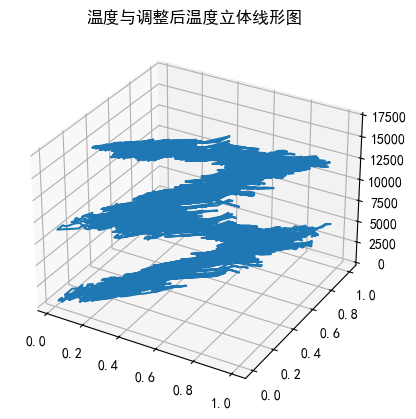

In [10]:
# 立体线形图（以温度和调整后温度的变化趋势为例）
print('立体线形图')
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(data_no_date['temp'], data_no_date['atemp'], np.arange(len(data_no_date)))
plt.title('温度与调整后温度立体线形图')
plt.show()

立体散点图


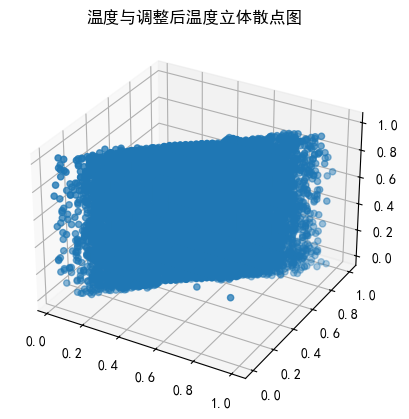

In [11]:
# 立体散点图（以温度和调整后温度为例）
print('立体散点图')
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data_no_date['temp'], data_no_date['atemp'], np.random.rand(len(data_no_date)))
plt.title('温度与调整后温度立体散点图')
plt.show()

立体柱状图


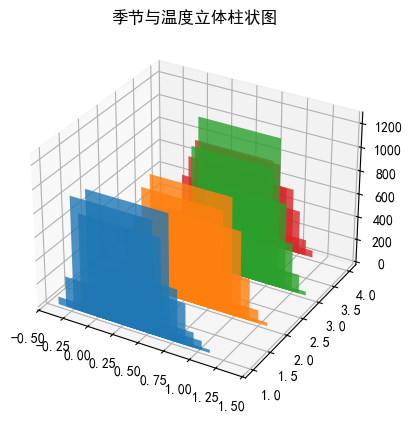

In [12]:
# 立体柱状图（以季节和温度为例）
print('立体柱状图')
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for season in data_no_date['season'].unique():
    season_data = data_no_date[data_no_date['season'] == season]['temp']
    hist, bins = np.histogram(season_data, bins=10)
    xs = np.linspace(min(bins), max(bins), len(hist))
    ax.bar(xs, hist, zs=season, zdir='y', alpha=0.8)
plt.title('季节与温度立体柱状图')
plt.show()

热力图


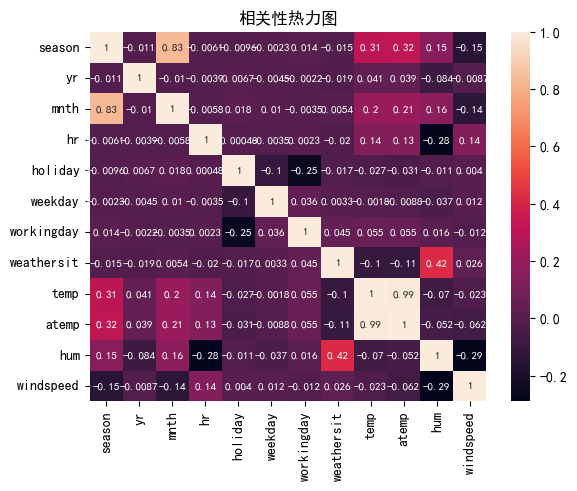

In [13]:
# 热力图（计算相关性矩阵并绘制）
print('热力图')
corr_matrix = data_no_date.corr()
sns.heatmap(corr_matrix, annot=True, annot_kws={"size": 8})
plt.title('相关性热力图')
plt.show()


箱线图


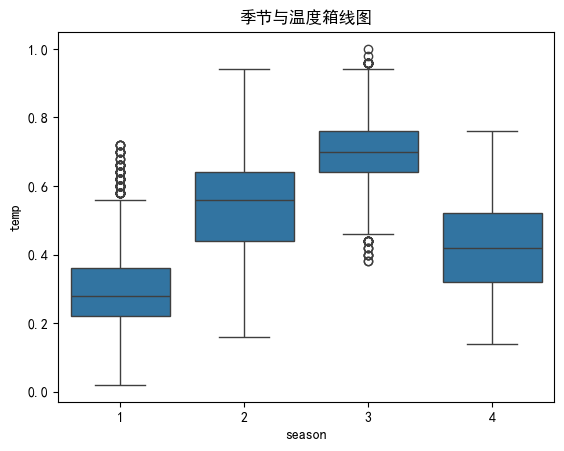

In [14]:
# 箱线图（以季节和温度为例）
print('箱线图')
sns.boxplot(data=data_no_date, x='season', y='temp')
plt.title('季节与温度箱线图')
plt.show()

小提琴图


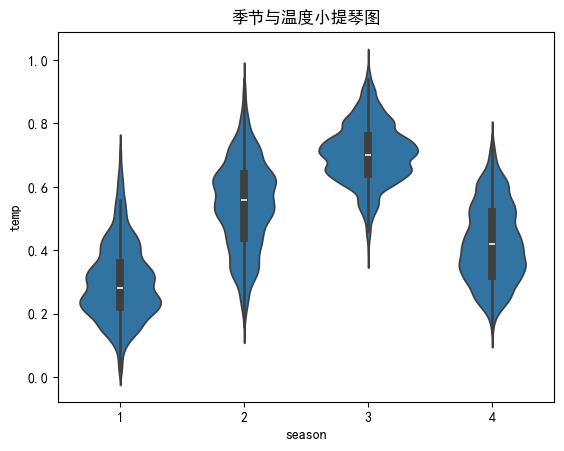

In [15]:
# 小提琴图（以季节和温度为例）
print('小提琴图')
sns.violinplot(data=data_no_date, x='season', y='temp')
plt.title('季节与温度小提琴图')
plt.show()

不同特征组合图


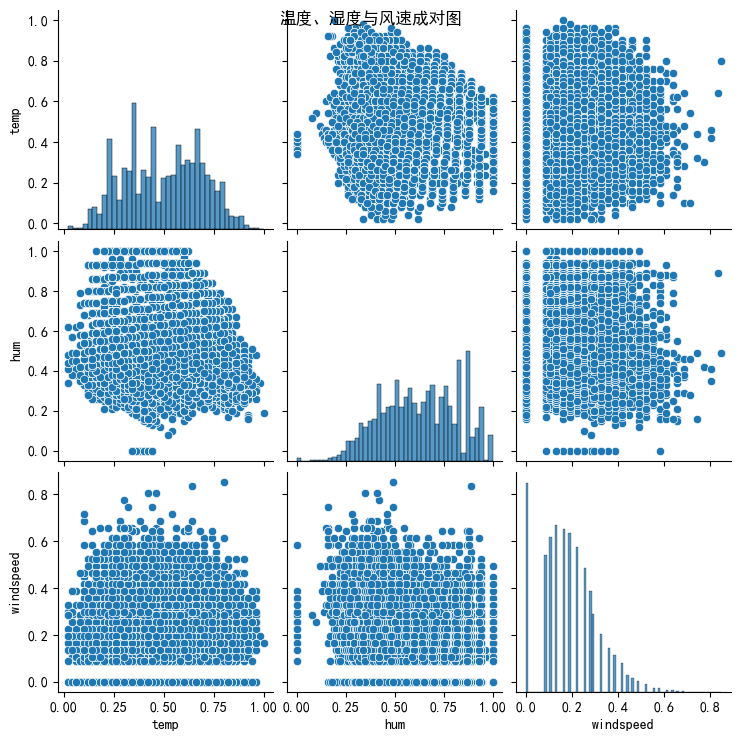

In [16]:
# 不同特征组合图（例如温度、湿度和风速的关系）
print('不同特征组合图')
sns.pairplot(data_no_date[['temp', 'hum', 'windspeed']])
plt.suptitle('温度、湿度与风速成对图')
plt.show()

带有逻辑回归模型的嵌入式散点分布图


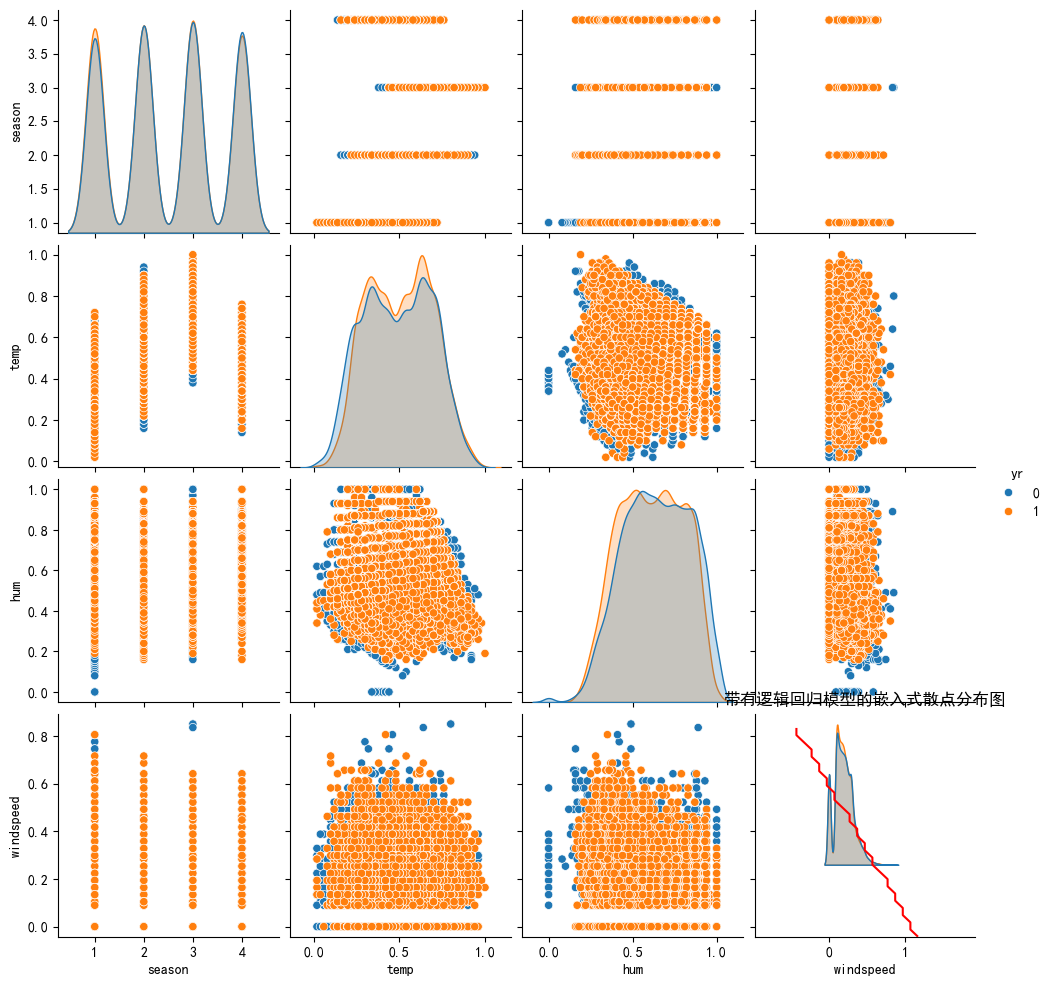

In [17]:
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

print('带有逻辑回归模型的嵌入式散点分布图')
# 选择部分特征用于可视化和建模
selected_features = ['season', 'temp', 'hum', 'windspeed']
data_for_plotting = data_no_date[selected_features]
target = data_no_date['yr']  # 根据实际情况修改目标列名称

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(data_for_plotting, target, test_size=0.2, random_state=42)

# 创建逻辑回归模型并训练
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# 预测测试集
y_pred = logreg.predict(X_test)

# 使用 seaborn 的 pairplot 绘制散点图矩阵，并区分不同目标类别
sns.pairplot(pd.concat([data_for_plotting, pd.DataFrame({'yr': target})], axis=1), hue='yr', vars=selected_features)

# 添加逻辑回归模型的决策边界（此部分较为复杂，需要根据具体特征维度进行计算和绘制，这里仅为示意）
# 假设二维情况，以 temp 和 hum 为例
temp_min, temp_max = data_for_plotting['temp'].min() - 1, data_for_plotting['temp'].max() + 1
hum_min, hum_max = data_for_plotting['hum'].min() - 1, data_for_plotting['hum'].max() + 1
# 创建一个与训练数据特征数量相同的网格数据
xx, yy = np.meshgrid(np.arange(temp_min, temp_max, 0.1),
                     np.arange(hum_min, hum_max, 0.1))
grid_points = np.c_[xx.ravel(), yy.ravel()]
# 填充其他两个特征为固定值，这里假设为均值
other_features_mean = np.array([data_for_plotting['season'].mean(), data_for_plotting['windspeed'].mean()])
full_grid_points = np.repeat(other_features_mean[np.newaxis, :], len(grid_points), axis=0)
full_grid_points = np.c_[full_grid_points, grid_points]

# 临时忽略警告
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    Z = logreg.predict(full_grid_points)

Z = Z.reshape(xx.shape)
plt.contour(xx, yy, Z, levels=[0.5], colors='r')

plt.title('带有逻辑回归模型的嵌入式散点分布图')
plt.show()

线性回归模型图


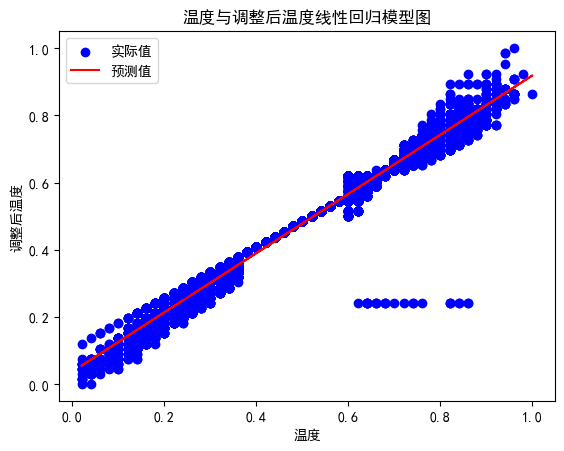

In [18]:
# 线性回归模型图（假设以温度和调整后温度进行线性回归）
print('线性回归模型图')
from sklearn.linear_model import LinearRegression
model = LinearRegression()
X_temp = data_no_date[['temp']]
y_atemp = data_no_date['atemp']
model.fit(X_temp, y_atemp)
y_pred = model.predict(X_temp)
plt.scatter(X_temp, y_atemp, color='blue', label='实际值')
plt.plot(X_temp, y_pred, color='red', label='预测值')
plt.title('温度与调整后温度线性回归模型图')
plt.xlabel('温度')
plt.ylabel('调整后温度')
plt.legend()
plt.show()


聚类模型图


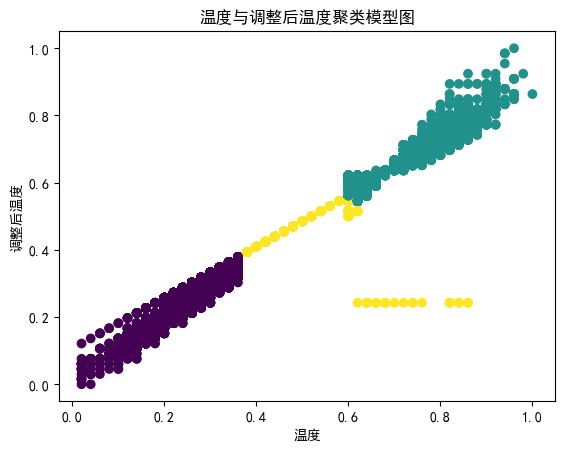

In [19]:
# 聚类模型图（以 KMeans 聚类为例，假设对温度和调整后温度进行聚类）
print('聚类模型图')
kmeans = KMeans(n_clusters=3)
X_cluster = data_no_date[['temp', 'atemp']]
kmeans.fit(X_cluster)
labels = kmeans.labels_
plt.scatter(X_cluster['temp'], X_cluster['atemp'], c=labels)
plt.title('温度与调整后温度聚类模型图')
plt.xlabel('温度')
plt.ylabel('调整后温度')
plt.show()

决策树模型图


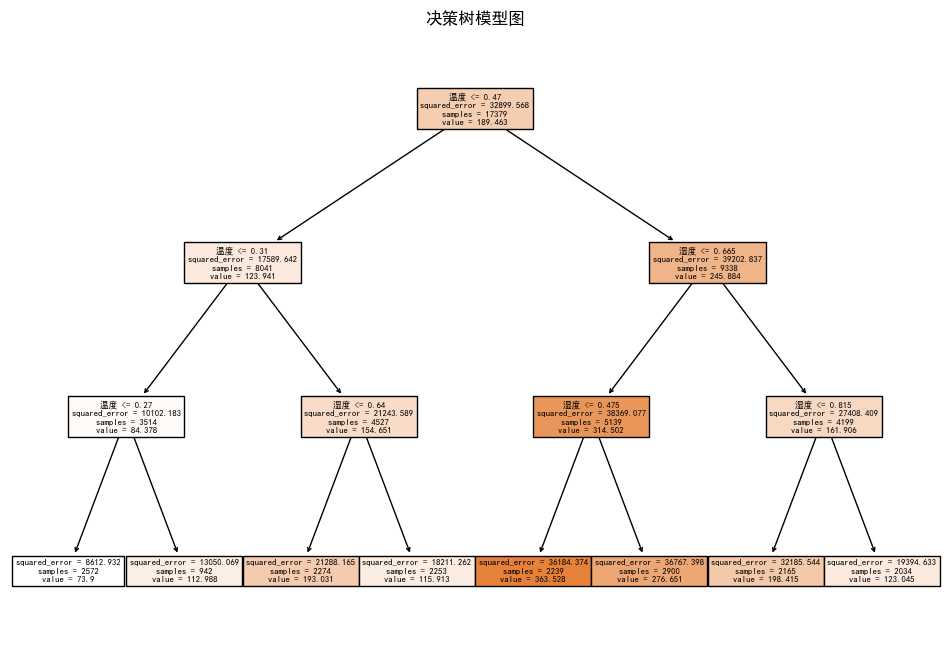

In [20]:
# 决策树模型图（假设以温度、湿度和风速预测某个目标）
print('决策树模型图')
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
dtree = DecisionTreeRegressor(max_depth=3)
X_tree = data_no_date[['temp', 'hum', 'windspeed']]
y_tree = targets['cnt']
dtree.fit(X_tree, y_tree)
fig = plt.figure(figsize=(12, 8))
tree.plot_tree(dtree, feature_names=['温度', '湿度', '风速'], filled=True)
plt.title('决策树模型图')
plt.show()

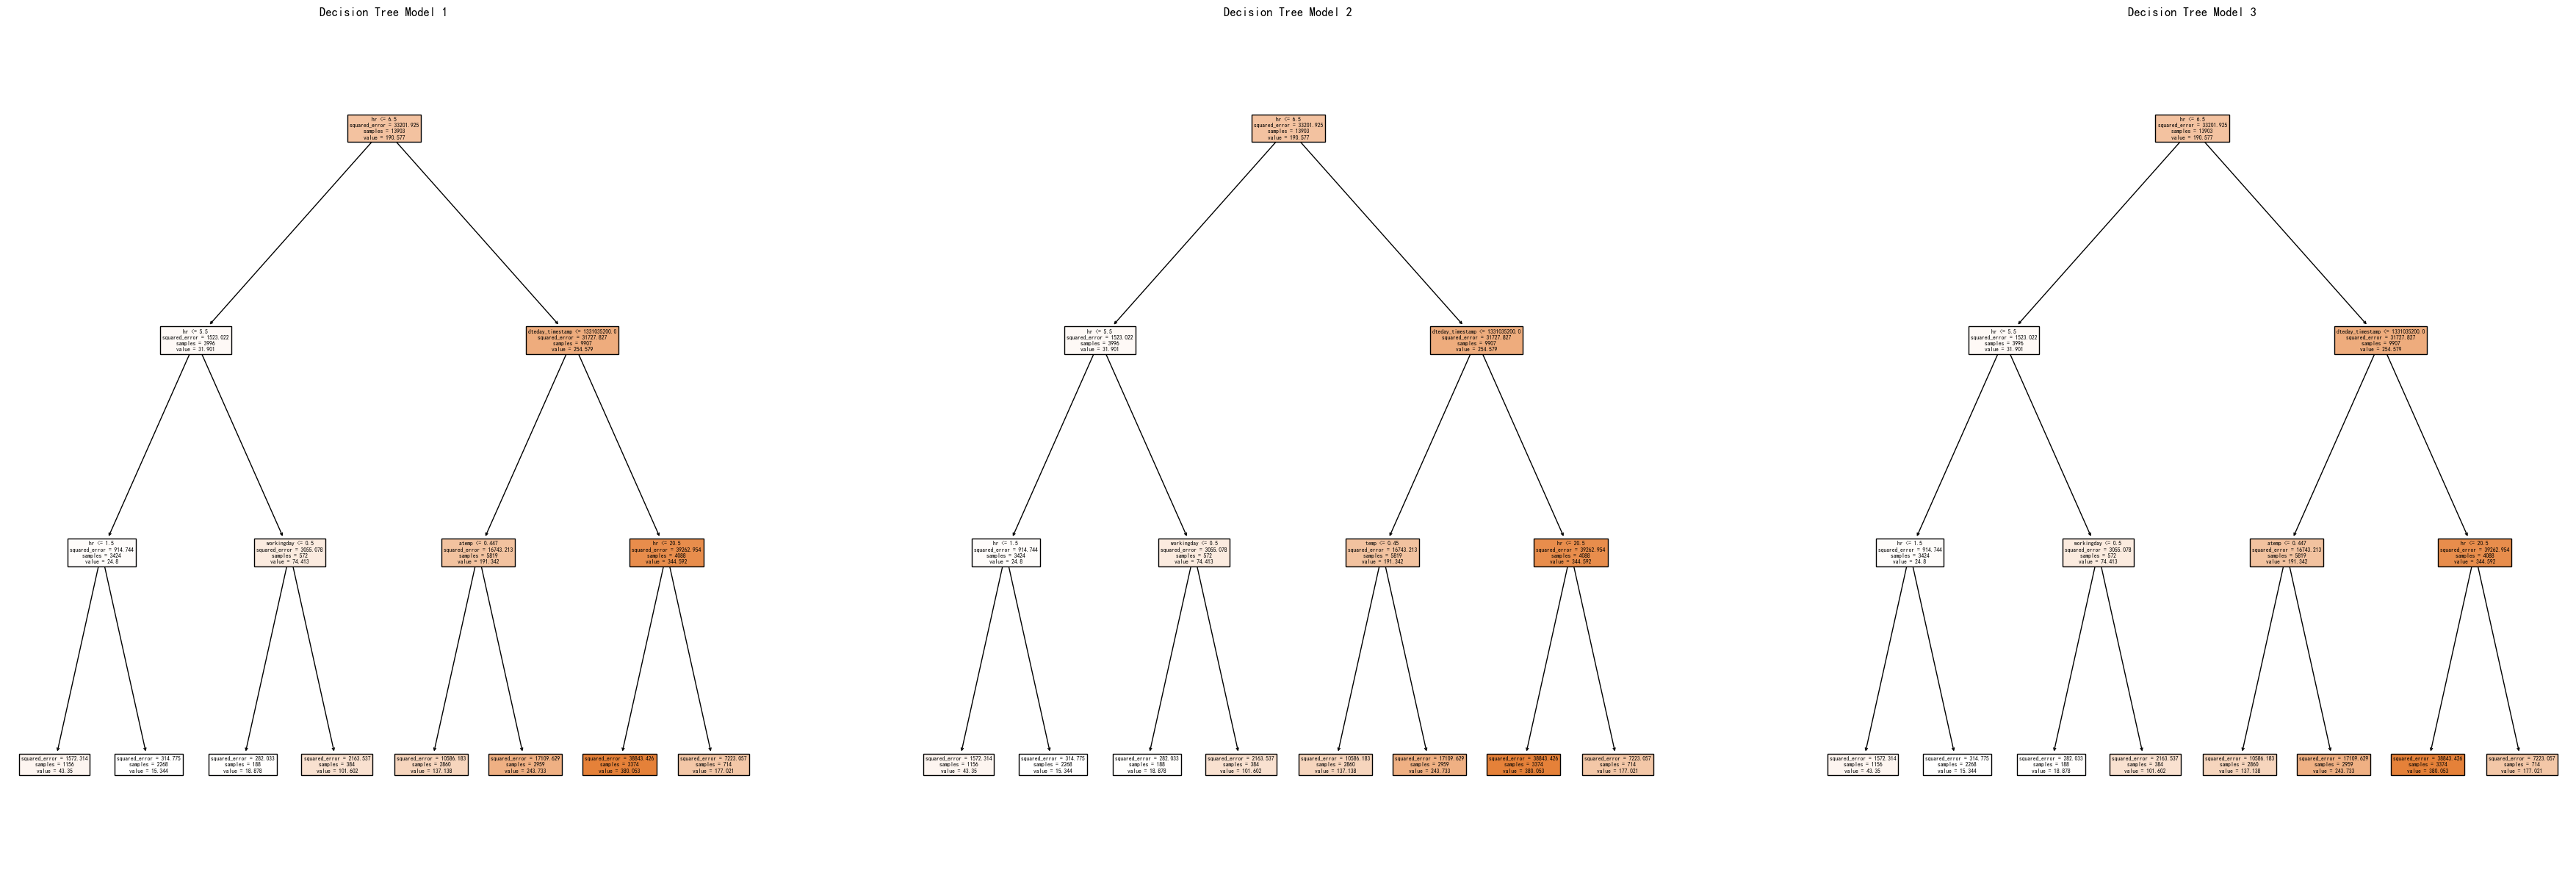

Decision Tree Model 3 MSE: 15639.339120232946


In [45]:
# 定义y
y = targets['cnt']

# 对日期数据进行处理
data['dteday'] = pd.to_datetime(data['dteday'])
data['year'] = data['dteday'].dt.year
data['month'] = data['dteday'].dt.month
data['day'] = data['dteday'].dt.day
X = data.drop('dteday', axis=1)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建一个大的图形对象
fig, axes = plt.subplots(1, 3, figsize=(45, 15))  # 1行3列的子图布局

for i in range(3):
    # 创建决策树模型，每次使用不同的随机种子
    model = DecisionTreeRegressor(max_depth=3, random_state=42 + i)
    model.fit(X_train, y_train)

    # 绘制决策树模型图
    plot_tree(model, filled=True, feature_names=X.columns, ax=axes[i])
    axes[i].set_title(f"Decision Tree Model {i + 1}")

plt.show()

# 计算均方误差（这里为了简洁，只展示了在测试集上最后一个模型的均方误差计算）
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Decision Tree Model 3 MSE: {mse}")

相关性网络图


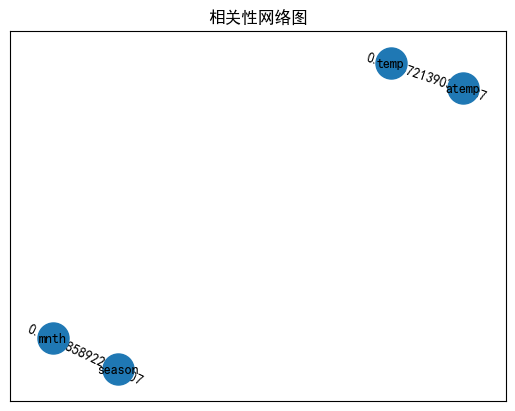

In [47]:
# 相关性网络图
print('相关性网络图')
corr_matrix = data_no_date.corr()
G = nx.Graph()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.5:  # 设置相关性阈值
            G.add_edge(corr_matrix.columns[i], corr_matrix.columns[j], weight=corr_matrix.iloc[i, j])
pos = nx.spring_layout(G)
nx.draw_networkx(G, pos, with_labels=True, node_size=500, font_size=10)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title('相关性网络图')
plt.show()

圆盘状显示网络图


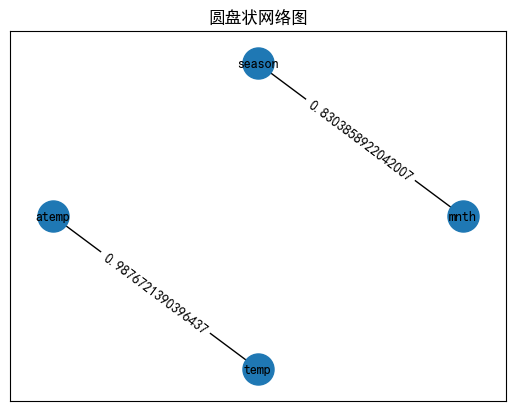

In [49]:
# 圆盘状显示的网络图
print('圆盘状显示网络图')
pos = nx.circular_layout(G)
nx.draw_networkx(G, pos, with_labels=True, node_size=500, font_size=10)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title('圆盘状网络图')
plt.show()

含属性及边的颜色及粗度表达的网络图


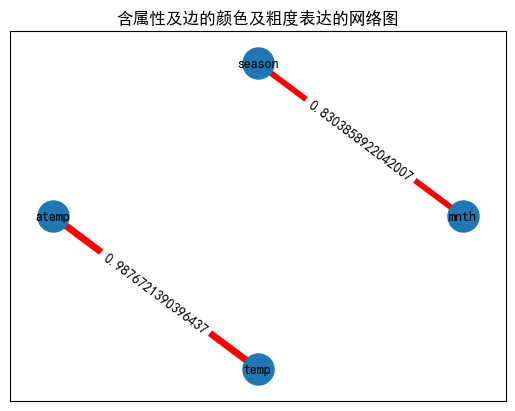

In [51]:
# 含属性及边的颜色及粗度表达的网络图
print('含属性及边的颜色及粗度表达的网络图')
colors = ['r' if abs(labels[e]) > 0.7 else 'b' for e in G.edges()]
widths = [abs(labels[e]) * 5 for e in G.edges()]
nx.draw_networkx(G, pos, with_labels=True, node_size=500, font_size=10, edge_color=colors, width=widths)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title('含属性及边的颜色及粗度表达的网络图')
plt.show()

环形布局的网络图


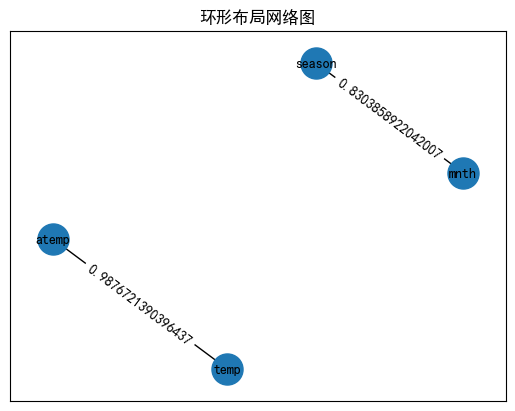

In [53]:
# 环形布局的网络图
print('环形布局的网络图')
pos = nx.kamada_kawai_layout(G)  # 环形布局算法之一
nx.draw_networkx(G, pos, with_labels=True, node_size=500, font_size=10)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title('环形布局网络图')
plt.show()

漏斗图


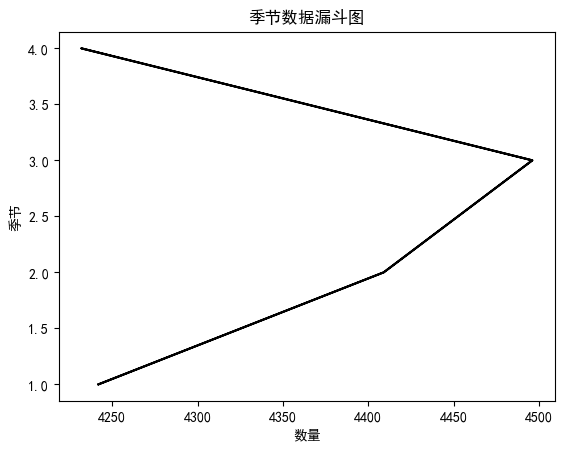

In [55]:
print('漏斗图')
# 假设data是包含数据的DataFrame
season_data = data['season'].value_counts().sort_index()
y_season = np.array(season_data.index)
x_season = np.array(season_data.values)

fig, ax = plt.subplots()
ax.set_title("季节数据漏斗图")
ax.set_xlabel("数量")
ax.set_ylabel("季节")

# 计算漏斗图中间点的坐标
mid_x_season = (x_season[:-1] + x_season[1:]) / 2
mid_y_season = (y_season[:-1] + y_season[1:]) / 2

# 绘制漏斗图
ax.plot(np.concatenate((x_season, x_season[::-1])), np.concatenate((y_season, y_season[::-1])), 'k-')
ax.fill(np.concatenate((x_season, x_season[::-1])), np.concatenate((y_season, y_season[::-1])), alpha=0.3)

plt.show()

             season            yr          mnth            hr       holiday
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000
mean       2.501640      0.502561      6.537775     11.546752      0.028770
std        1.106918      0.500008      3.438776      6.914405      0.167165
min        1.000000      0.000000      1.000000      0.000000      0.000000
25%        2.000000      0.000000      4.000000      6.000000      0.000000
50%        3.000000      1.000000      7.000000     12.000000      0.000000
75%        3.000000      1.000000     10.000000     18.000000      0.000000
max        4.000000      1.000000     12.000000     23.000000      1.000000


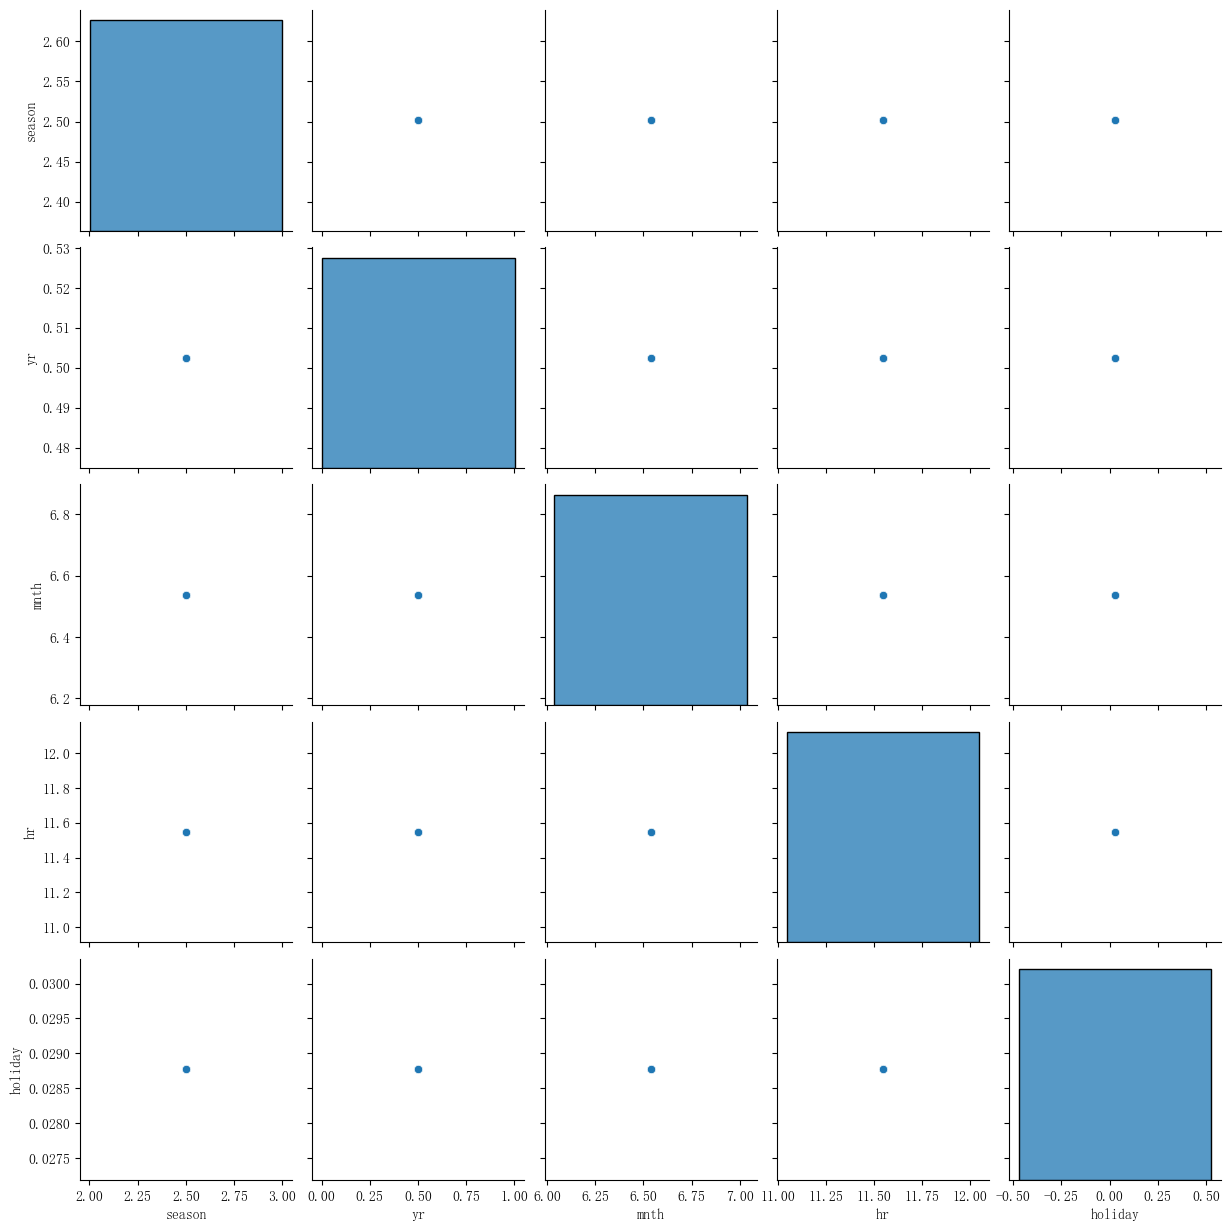

In [57]:
   import pandas as pd
   import numpy as np
   import matplotlib.pyplot as plt
   from matplotlib.font_manager import FontProperties
   from sklearn.preprocessing import MinMaxScaler

   # 假设data是从bike_sharing数据集提取的数据
   selected_data = data[['season', 'yr', 'mnth', 'hr', 'holiday']]
   scaler = MinMaxScaler()
   selected_data_scaled = scaler.fit_transform(selected_data)

   font = FontProperties(fname="C:\\Windows\\Fonts\\simsun.ttc", size=12)
   plt.rcParams['font.sans-serif'] = font.get_name()
   plt.rcParams['axes.unicode_minus'] = False
   print(selected_data.describe())
import pandas as pd
import seaborn as sns

# 假设data是包含数据的DataFrame
data = pd.DataFrame({
    'season': [2.501640] * 17379,
    'yr': [0.502561] * 17379,
    'mnth': [6.537775] * 17379,
    'hr': [11.546752] * 17379,
    'holiday': [0.028770] * 17379
})

# 绘制散点图矩阵
sns.pairplot(data)
plt.show()


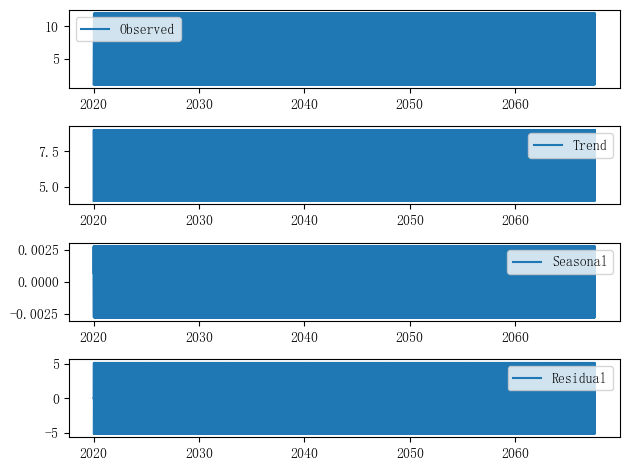

In [58]:
#季节性分解图（以月份数据为例，假设数据有时间序列特征）
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 假设data是包含数据的DataFrame，这里模拟一个简单的月份数据
data = pd.DataFrame({
    'mnth': list(range(1, 13)) * 1448
})

# 将数据转换为时间序列格式
data['date'] = pd.date_range(start='2020-01-01', periods=len(data))
data.set_index('date', inplace=True)

# 进行季节性分解
decomposition = seasonal_decompose(data['mnth'], model='additive')

# 绘制分解结果
plt.subplot(411)
plt.plot(decomposition.observed, label='Observed')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(decomposition.resid, label='Residual')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [59]:
#关联规则挖掘图（这里使用 mlxtend 库，先对数据进行简单处理）
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# 假设data是包含数据的DataFrame
data = pd.DataFrame({
    'season': [2.501640] * 17379,
    'yr': [0.502561] * 17379,
    'mnth': [6.537775] * 17379,
    'hr': [11.546752] * 17379,
    'holiday': [0.028770] * 17379
})

# 简单离散化处理，这里以hr为例，分为白天和夜晚
data['hr_discrete'] = data['hr'].apply(lambda x: 'day' if 6 <= x <= 18 else 'night')

# 转换数据格式用于关联规则挖掘
transactions = []
for i in range(len(data)):
    row = []
    if data.loc[i, 'season'] >= 3:
        row.append('summer')
    else:
        row.append('winter')
    if data.loc[i, 'yr'] >= 0.5:
        row.append('yr2')
    else:
        row.append('yr1')
    if data.loc[i, 'mnth'] >= 6:
        row.append('second_half_year')
    else:
        row.append('first_half_year')
    row.append(data.loc[i, 'hr_discrete'])
    if data.loc[i, 'holiday'] >= 0.5:
        row.append('holiday')
    else:
        row.append('non - holiday')
    transactions.append(row)

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

# 挖掘频繁项集
frequent_itemsets = apriori(df, min_support=0.1, use_colnames=True)

# 生成关联规则
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
print(rules)

            antecedents                                     consequents  \
0       (non - holiday)                                           (day)   
1                 (day)                                 (non - holiday)   
2    (second_half_year)                                           (day)   
3                 (day)                              (second_half_year)   
4                 (day)                                        (winter)   
..                  ...                                             ...   
175               (day)  (second_half_year, non - holiday, yr2, winter)   
176               (yr2)  (second_half_year, non - holiday, day, winter)   
177     (non - holiday)            (second_half_year, day, yr2, winter)   
178  (second_half_year)               (non - holiday, day, yr2, winter)   
179            (winter)     (second_half_year, non - holiday, day, yr2)   

     antecedent support  consequent support  support  confidence  lift  \
0                   1.0  

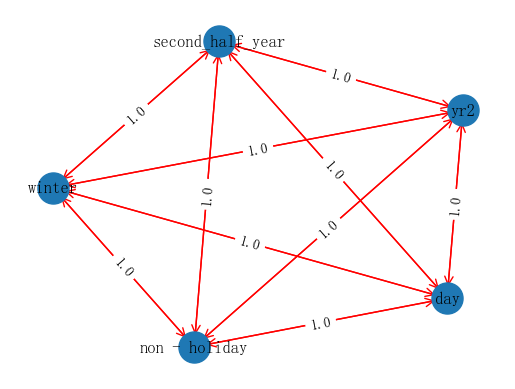

In [63]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# 假设rules是关联规则挖掘得到的结果DataFrame
# 这里以之前得到的rules为例

# 创建有向图
G = nx.DiGraph()

# 添加节点
for antecedents in rules['antecedents']:
    for antecedent in antecedents:
        G.add_node(antecedent)
for consequents in rules['consequents']:
    for consequent in consequents:
        G.add_node(consequent)

# 添加边，边的权重用置信度表示
for index, row in rules.iterrows():
    antecedents = row['antecedents']
    consequents = row['consequents']
    confidence = row['confidence']
    for antecedent in antecedents:
        for consequent in consequents:
            G.add_edge(antecedent, consequent, weight=confidence)

# 绘制图形
pos = nx.spring_layout(G)
nx.draw_networkx_nodes(G, pos, node_size=500)
nx.draw_networkx_labels(G, pos)
nx.draw_networkx_edges(G, pos, edge_color='r', arrowstyle='->', arrowsize=15)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.axis('off')
plt.show()